# Introducción

**HELP International** es una ONG humanitaria internacional dedicada a combatir la pobreza y brindar a las personas de países en desarrollo servicios básicos y ayuda humanitaria durante desastres y calamidades naturales. HELP International ha logrado recaudar alrededor de 10 millones de dólares. Este dinero ahora debe asignarse de manera estratégica y eficaz. Por lo tanto, para seleccionar los países que más necesitan ayuda, se deben tomar decisiones basadas en datos. Así, es necesario categorizar los países utilizando factores socioeconómicos y de salud que determinan su desarrollo general. De esta manera, con base en estos grupos de países según sus condiciones, se asignarán fondos para la asistencia durante desastres y calamidades naturales.

- **Objetivo:** Agrupar países según las diferentes características presentes

### DATASET

- **country:** Name of the country
- **child_mort:** Muerte de niños menores de 5 años por cada 1000 nacidos vivos
- **exports:** Exportaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita
- **health:** Gasto total en salud per cápita. Expresado como porcentaje del PIB per cápita
- **imports:** Importaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita
- **Income:** Ingreso neto por persona
- **Inflation:** Medida de la tasa de crecimiento anual del PIB total
- **life_expec:** Promedio de años que viviría un recién nacido si se mantuvieran los patrones de mortalidad actuales
- **total_fer:** Número de hijos que tendría cada mujer si se mantuvieran las tasas de fecundidad actuales
- **gdpp:** Calculado como el PIB total dividido por la población total

# LECTURA DE LOS DATOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from ydata_profiling import ProfileReport
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA


# !pip install -U kaleido
import kaleido

In [2]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

In [3]:
data = pd.read_csv('data/Country-data.csv')
data.head()
data_original = data.copy()

In [4]:
#from google.colab import files
#files.upload()

#data = pd.read_csv('Country-data.csv')

In [5]:
data.shape

(167, 10)

In [6]:
#!pip install ydata_profiling

#from ydata_profiling import ProfileReport


#profile = ProfileReport(data, title="Análisis Exploratorio de Mi DataFrame")
#profile

In [7]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.79,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [8]:
# Eliminamos la etiqueta de texto
X_raw = data.drop('country', axis=1)

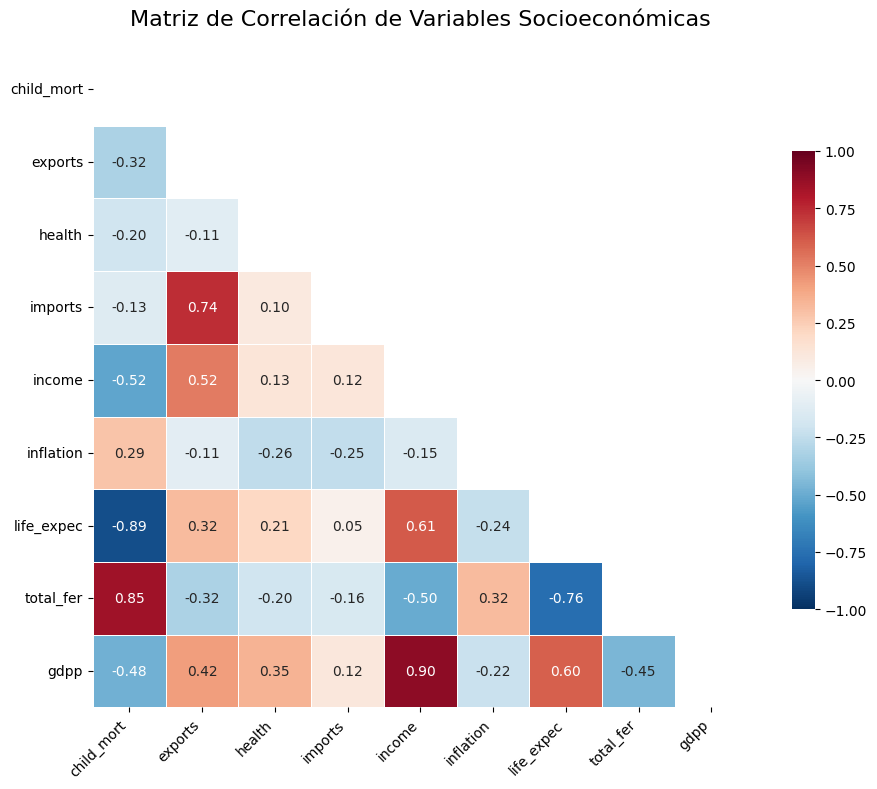

In [9]:
# Calcular la matriz de correlación

# Excluimos la columna 'country' ya que no es numérica
corr_matrix = data.drop('country', axis=1).corr()


plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generar el Heatmap
sns.heatmap(corr_matrix, 
            mask=mask,            # Aplicamos la máscara
            cmap='RdBu_r',        # Paleta divergente (Rojo=Positivo, Azul=Negativo)
            vmax=1, vmin=-1,      # Fijar los límites en +1 y -1
            center=0,             # El centro (blanco) es correlación 0
            square=True,          # Forzar a que las celdas sean cuadradas
            linewidths=.5,        # Líneas blancas divisorias para limpieza visual
            cbar_kws={"shrink": .7}, # Ajustar tamaño barra lateral
            annot=True,           # Mostrar los valores numéricos
            fmt=".2f",            # Solo 2 decimales
            annot_kws={"size": 10}) # Tamaño de los números

plt.title('Matriz de Correlación de Variables Socioeconómicas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas eje X para leerlas mejor
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

# ESCALADO Y PCA

In [10]:
# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [11]:
# Aplicar PCA (Todas las componentes)
pca_full = PCA()
pca_full.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
# Pesos (Loadings) de las variables originales

components_matrix = pca_full.components_
feature_names = X_raw.columns

# Crear el DataFrame con los pesos
df_loadings = pd.DataFrame(
    components_matrix,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(components_matrix))]
)

df_loadings

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
PC1,-0.42,0.28,0.15,0.16,0.40,-0.19,0.43,-0.40,0.39
PC2,0.19,0.61,-0.24,0.67,0.02,-0.01,-0.22,0.16,-0.05
PC3,-0.03,0.14,-0.60,-0.30,0.30,0.64,0.11,0.02,0.12
PC4,0.37,0.00,0.46,-0.07,0.39,0.15,-0.20,0.38,0.53
PC5,-0.17,0.06,0.52,0.26,-0.25,0.71,0.11,-0.14,-0.18
PC6,-0.20,0.06,-0.01,0.03,-0.16,-0.07,0.60,0.75,-0.02
PC7,0.08,0.71,0.25,-0.59,-0.10,-0.10,-0.02,-0.03,-0.24
PC8,0.68,0.01,-0.07,0.03,-0.35,0.01,0.50,-0.29,0.25
PC9,-0.33,0.12,-0.11,-0.10,-0.61,0.03,-0.29,0.03,0.63


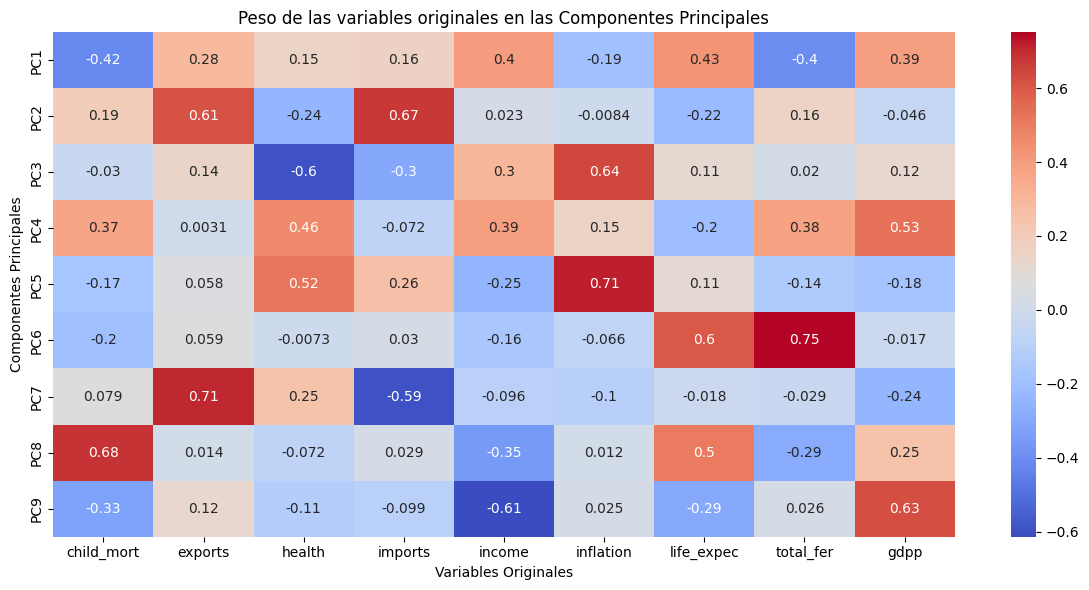

In [13]:
# GRAFICO A: Pesos (Loadings) de las variables originales
plt.figure(figsize=(12, 6))
# Mostramos todas las componentes o solo las primeras para que sea legible
components_matrix = pca_full.components_
feature_names = X_raw.columns
sns.heatmap(components_matrix, annot=True, cmap='coolwarm', 
            xticklabels=feature_names, 
            yticklabels=[f'PC{i+1}' for i in range(len(components_matrix))])
plt.title('Peso de las variables originales en las Componentes Principales')
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.tight_layout()
plt.show()

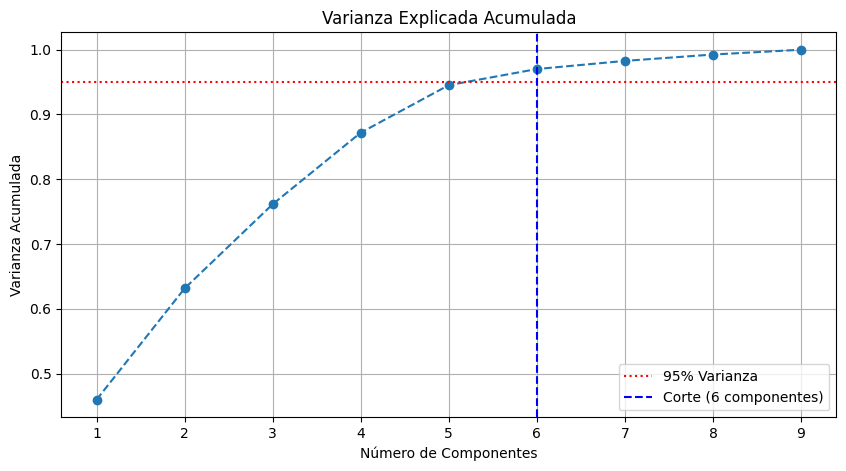

In [14]:
# GRAFICO B: Varianza Acumulada

plt.figure(figsize=(10, 5))
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Calcular cuántas componentes se necesitan para el 95% de varianza
n_components_95 = np.argmax(cum_var >= 0.95) + 1

plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Varianza')
plt.axvline(x=n_components_95, color='b', linestyle='--', label=f'Corte ({n_components_95} componentes)')

plt.title('Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# COMPARACIÓN DE MODELOS

### PCA 5 componentes

In [15]:
# REDUCCIÓN DE DIMENSIONALIDAD (Quedarse con 5 componentes)
pca_5 = PCA(n_components=5)
X_pca_5 = pca_5.fit_transform(X_scaled)

cols = [f'PC{i+1}' for i in range(5)] # Crea nombres ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
df_pca_5 = pd.DataFrame(X_pca_5, columns=cols)
df_pca_5.head()

,PC1,PC2,PC3,PC4,PC5
0,-2.91,0.10,-0.72,1.01,-0.16
1,0.43,-0.59,-0.33,-1.16,0.17
2,-0.29,-0.46,1.22,-0.87,0.16
3,-2.93,1.70,1.53,0.84,-0.27
4,1.03,0.14,-0.23,-0.85,-0.19


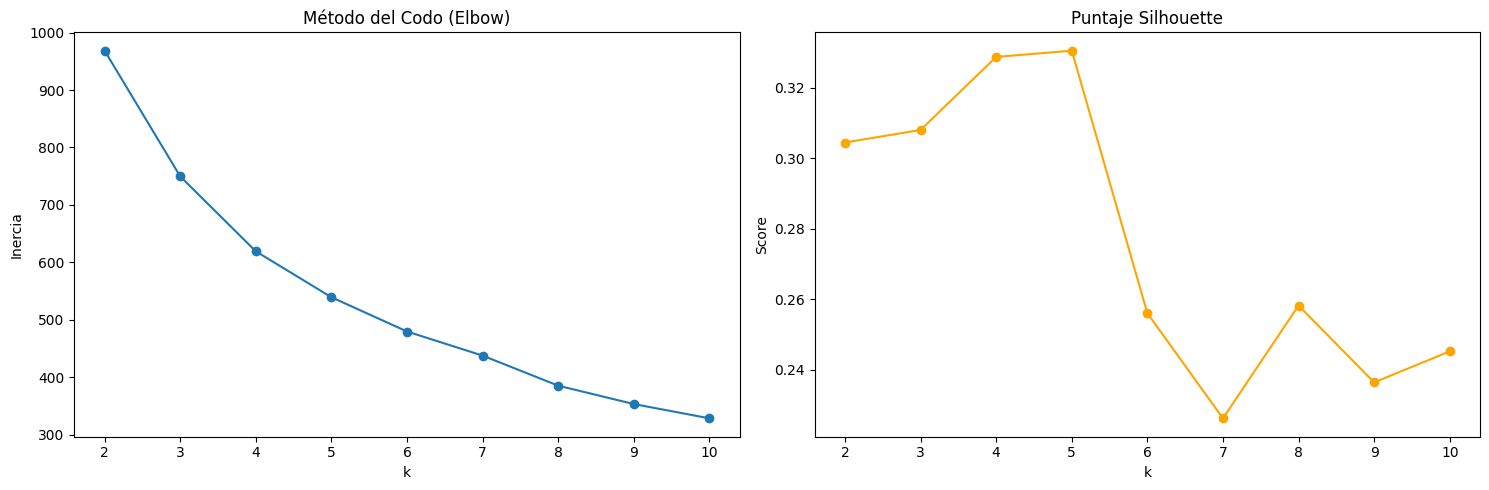

In [16]:
# GRAFICO C: Codo y Silhouette para determinar k (usando X_pca_5)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Ajustamos K-Means sobre los datos reducidos (PCA)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_5)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_5, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Codo
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Método del Codo (Elbow)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inercia')

# Silhouette
ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Puntaje Silhouette')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [17]:
# K-MEANS (k=5)

kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
# Entrenamos con los datos reducidos
labels = kmeans_final.fit_predict(X_pca_5)

# Imprimir métrica Silhouette
final_sil = silhouette_score(X_pca_5, labels)
print(f"\n>>> Silhouette Score (k=5) sobre datos PCA (5 comps): {final_sil:.4f}")

# Imprimir número de puntos por cluster
unique, counts = np.unique(labels, return_counts=True)
print("\n>>> Número de puntos por cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"    Cluster {cluster_id}: {count} países")


>>> Silhouette Score (k=5) sobre datos PCA (5 comps): 0.3305

>>> Número de puntos por cluster:
    Cluster 0: 86 países
    Cluster 1: 30 países
    Cluster 2: 47 países
    Cluster 3: 3 países
    Cluster 4: 1 países


### PCA 4 componentes

In [18]:
pca_4 = PCA(n_components=4)
X_pca_4 = pca_4.fit_transform(X_scaled)

cols = [f'PC{i+1}' for i in range(4)] # Crea nombres ['PC1', 'PC2', 'PC3', 'PC4']
df_pca_4 = pd.DataFrame(X_pca_4, columns=cols)
df_pca_4.head()

,PC1,PC2,PC3,PC4
0,-2.91,0.10,-0.72,1.01
1,0.43,-0.59,-0.33,-1.16
2,-0.29,-0.46,1.22,-0.87
3,-2.93,1.70,1.53,0.84
4,1.03,0.14,-0.23,-0.85


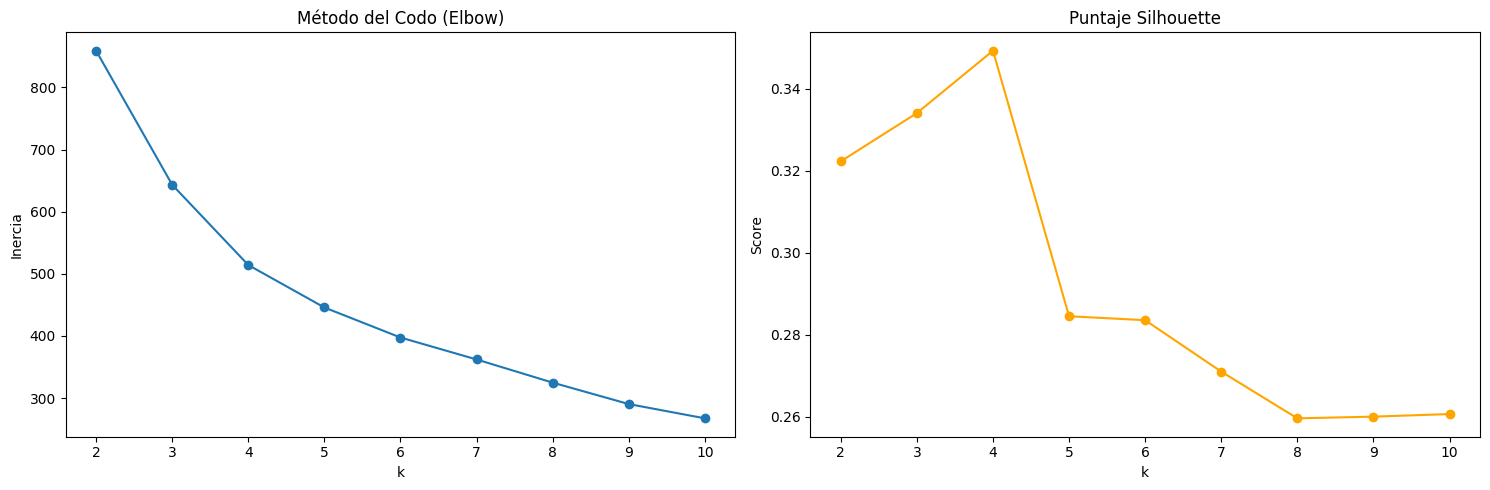

In [19]:
# GRAFICO C: Codo y Silhouette para determinar k (usando X_pca_4)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Ajustamos K-Means sobre los datos reducidos (PCA)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_4)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_4, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Codo
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Método del Codo (Elbow)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inercia')

# Silhouette
ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Puntaje Silhouette')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [20]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
# Entrenamos con los datos reducidos
labels = kmeans_final.fit_predict(X_pca_4)

# Imprimir métrica Silhouette
final_sil = silhouette_score(X_pca_4, labels)
print(f"\n>>> Silhouette Score (k=4) sobre datos PCA (4 comps): {final_sil:.4f}")

# Imprimir número de puntos por cluster
unique, counts = np.unique(labels, return_counts=True)
print("\n>>> Número de puntos por cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"    Cluster {cluster_id}: {count} países")


>>> Silhouette Score (k=4) sobre datos PCA (4 comps): 0.3493

>>> Número de puntos por cluster:
    Cluster 0: 47 países
    Cluster 1: 31 países
    Cluster 2: 86 países
    Cluster 3: 3 países


### PCA 6 componentes

In [21]:
pca_6 = PCA(n_components=6)
X_pca_6 = pca_6.fit_transform(X_scaled)

cols = [f'PC{i+1}' for i in range(6)] # Crea nombres ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']
df_pca_6 = pd.DataFrame(X_pca_6, columns=cols)
df_pca_6.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.91,0.10,-0.72,1.01,-0.16,0.25
1,0.43,-0.59,-0.33,-1.16,0.17,-0.08
2,-0.29,-0.46,1.22,-0.87,0.16,0.40
3,-2.93,1.70,1.53,0.84,-0.27,0.55
4,1.03,0.14,-0.23,-0.85,-0.19,0.21


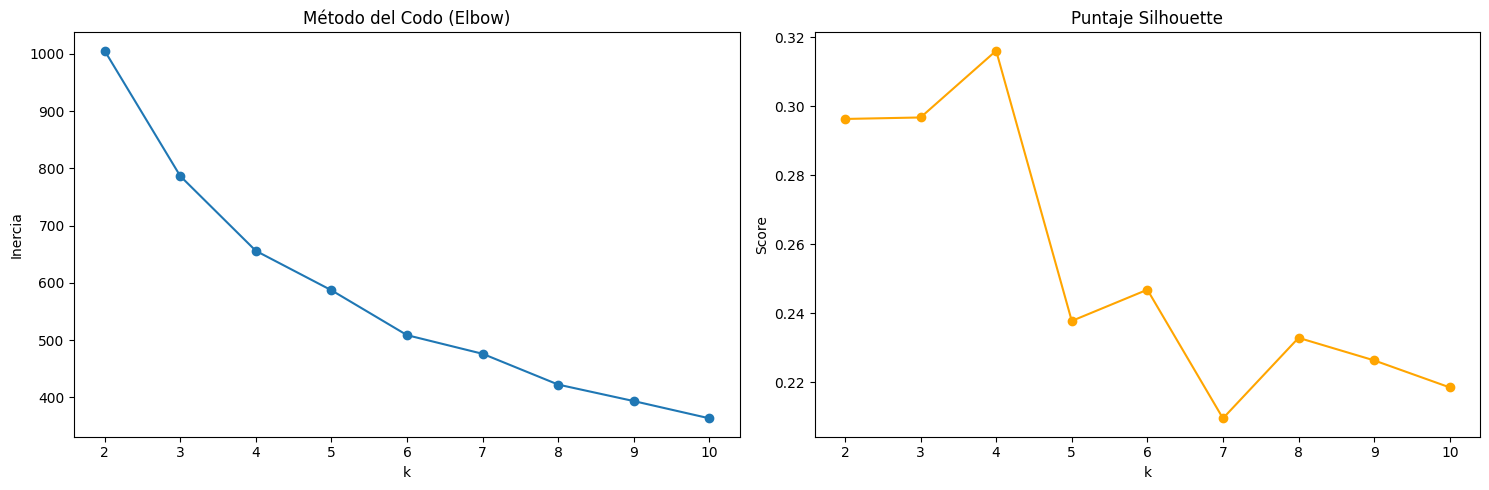

In [22]:
# GRAFICO C: Codo y Silhouette para determinar k (usando X_pca_6)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Ajustamos K-Means sobre los datos reducidos (PCA)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_6)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_6, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Codo
ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Método del Codo (Elbow)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inercia')

# Silhouette
ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Puntaje Silhouette')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [23]:
# K-MEANS (k=4)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
# Entrenamos con los datos reducidos
labels = kmeans_final.fit_predict(X_pca_6)

# Imprimir métrica Silhouette
final_sil = silhouette_score(X_pca_6, labels)
print(f"\n>>> Silhouette Score (k=4) sobre datos PCA (6 comps): {final_sil:.4f}")

# Imprimir número de puntos por cluster
unique, counts = np.unique(labels, return_counts=True)
print("\n>>> Número de puntos por cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"    Cluster {cluster_id}: {count} países")


>>> Silhouette Score (k=4) sobre datos PCA (6 comps): 0.3162

>>> Número de puntos por cluster:
    Cluster 0: 88 países
    Cluster 1: 30 países
    Cluster 2: 46 países
    Cluster 3: 3 países


# Mejor opción: PCA (4 componentes), K-MEANS (k=4)

In [24]:
# K-MEANS FINAL (k=4)

pca_4 = PCA(n_components=4)
X_pca_4 = pca_4.fit_transform(X_scaled)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X_pca_4)

# Imprimir métrica Silhouette
final_sil = silhouette_score(X_pca_4, labels)
print(f"\n>>> Silhouette Score (k=4) sobre datos PCA (4 comps): {final_sil:.4f}")

# Imprimir número de puntos por cluster
unique, counts = np.unique(labels, return_counts=True)
print("\n>>> Número de puntos por cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"    Cluster {cluster_id}: {count} países")


>>> Silhouette Score (k=4) sobre datos PCA (4 comps): 0.3493

>>> Número de puntos por cluster:
    Cluster 0: 47 países
    Cluster 1: 31 países
    Cluster 2: 86 países
    Cluster 3: 3 países


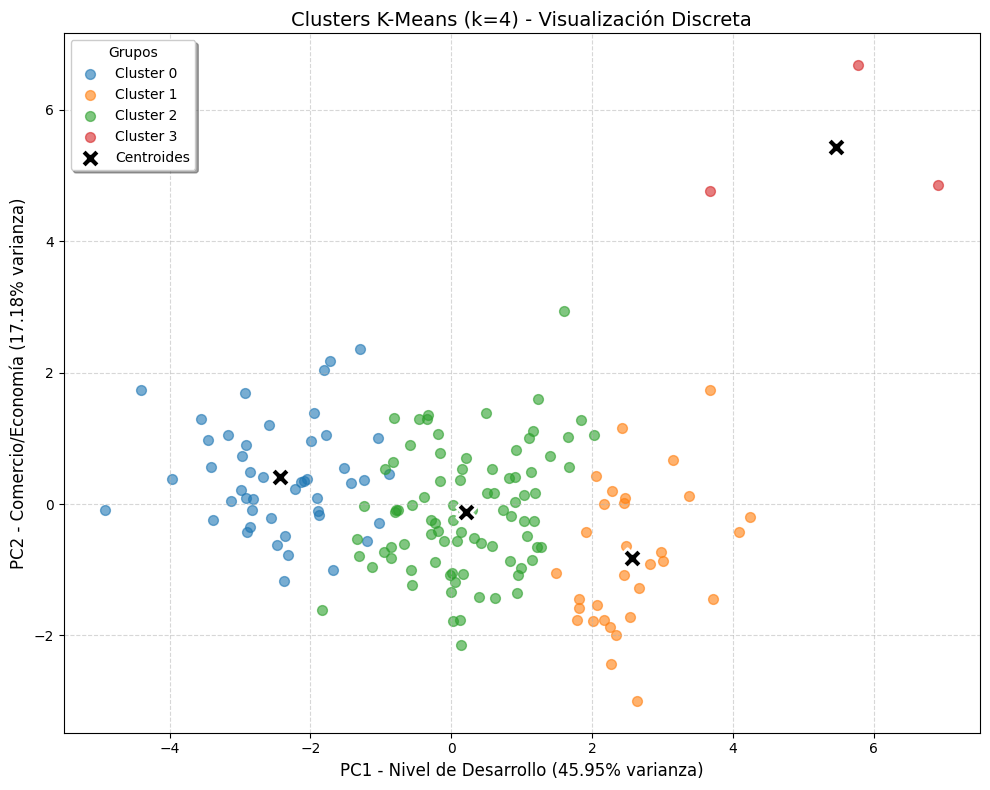

In [25]:
# GRAFICO D: Visualización en 2D (PC1 vs PC2) con Centroides

plt.figure(figsize=(10, 8))

# Definimos una paleta de colores
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Azul, Naranja, Verde, Rojo

# Bucle para dibujar cada cluster por separado y asignarle su etiqueta en la leyenda
for i in range(4):
    # Filtramos los puntos que pertenecen al cluster 'i'
    points = X_pca_4[labels == i]
    
    plt.scatter(points[:, 0], points[:, 1], 
                s=50,                  # Tamaño del punto
                c=colors[i],           # Color fijo para este cluster
                alpha=0.6,             # Transparencia
                label=f'Cluster {i}')  # Etiqueta para la leyenda

# Dibujar los centroides
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], 
            c='black', s=200, marker='X', 
            label='Centroides', edgecolors='white', linewidth=2)

# Títulos y Ejes
plt.title('Clusters K-Means (k=4) - Visualización Discreta', fontsize=14)
plt.xlabel(f'PC1 - Nivel de Desarrollo ({pca_full.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
plt.ylabel(f'PC2 - Comercio/Economía ({pca_full.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)

# Añadir la leyenda en una posición óptima
plt.legend(title="Grupos", loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# INTERPRETACIÓN DE LOS RESULTADOS

## INTERPRETACIÓN DE LOS CLUSTER

In [26]:
#  PROMEDIOS POR CLUSTER

data_original['Cluster'] = labels
# Agrupamos por cluster y calculamos la media de las variables originales
cluster_means = data_original.groupby('Cluster').mean(numeric_only=True)
cluster_counts = data_original['Cluster'].value_counts().sort_index()

# Añadimos la columna de conteo para saber cuántos países hay
cluster_means['Count'] = cluster_counts

print("\n>>> TABLA 1: Promedios de variables originales por Cluster")
cluster_means


>>> TABLA 1: Promedios de variables originales por Cluster


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Count
Cluster,,,,,,,,,,
0,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
1,4.90,46.48,9.13,40.48,44703.23,2.61,80.28,1.79,42574.19,31
2,21.60,41.00,6.22,47.87,12790.35,7.52,72.88,2.30,6769.33,86
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67,3


In [27]:
# COMPARACIÓN CON LA MEDIA GLOBAL
global_mean = data.drop('country', axis=1).mean()

print("\n>>> TABLA 2: Media Global del Dataset")
display(global_mean)

# Creamos una tabla de desviación porcentual
# Fórmula: ((Media_Cluster - Media_Global) / Media_Global) * 100
# Esto nos dice: "El Cluster X tiene un PIB un 50% mayor que la media mundial"
relative_means = (cluster_means.drop('Count', axis=1) - global_mean) / global_mean * 100

print("\n>>> TABLA 3: Desviación Porcentual respecto a la Media Global (%)")
print("    (Valores positivos = Por encima de la media, Negativos = Por debajo)")
relative_means


>>> TABLA 2: Media Global del Dataset


child_mort      38.27
exports         41.11
health           6.82
imports         46.89
income       17144.69
inflation        7.78
life_expec      70.56
total_fer        2.95
gdpp         12964.16
dtype: float64


>>> TABLA 3: Desviación Porcentual respecto a la Media Global (%)
    (Valores positivos = Por encima de la media, Negativos = Por debajo)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,142.91,-29.09,-6.27,-9.74,-77.01,54.46,-16.11,69.88,-85.17
1,-87.19,13.06,33.91,-13.66,160.74,-66.49,13.79,-39.41,228.40
2,-43.56,-0.26,-8.79,2.08,-25.40,-3.41,3.30,-22.13,-47.78
3,-89.20,328.13,-0.33,234.11,273.49,-68.29,15.42,-53.19,344.04


In [28]:
# INTERPRETACIÓN AUTOMÁTICA BASADA EN DATOS
print("\n>>> INTERPRETACIÓN RÁPIDA DE LOS CLUSTERS:")
for i in cluster_means.index:
    cmort = cluster_means.loc[i, 'child_mort']
    income = cluster_means.loc[i, 'income']
    gdpp = cluster_means.loc[i, 'gdpp']
    
    tipo = "Indefinido"
    if gdpp > 40000:
        tipo = "Países Ricos / Microestados Financieros"
    elif gdpp > 20000:
        tipo = "Países Desarrollados"
    elif cmort > 60: # Alta mortalidad infantil
        tipo = "Países Subdesarrollados / Alta Pobreza"
    else:
        tipo = "Países en Vías de Desarrollo"
        
    print(f"Cluster {i} ({cluster_counts[i]} países): {tipo}")
    print(f"   - GDPP: ${gdpp:.0f} (Media Global: ${global_mean['gdpp']:.0f})")
    print(f"   - Mort. Infantil: {cmort:.1f} (Media Global: {global_mean['child_mort']:.1f})")


>>> INTERPRETACIÓN RÁPIDA DE LOS CLUSTERS:
Cluster 0 (47 países): Países Subdesarrollados / Alta Pobreza
   - GDPP: $1922 (Media Global: $12964)
   - Mort. Infantil: 93.0 (Media Global: 38.3)
Cluster 1 (31 países): Países Ricos / Microestados Financieros
   - GDPP: $42574 (Media Global: $12964)
   - Mort. Infantil: 4.9 (Media Global: 38.3)
Cluster 2 (86 países): Países en Vías de Desarrollo
   - GDPP: $6769 (Media Global: $12964)
   - Mort. Infantil: 21.6 (Media Global: 38.3)
Cluster 3 (3 países): Países Ricos / Microestados Financieros
   - GDPP: $57567 (Media Global: $12964)
   - Mort. Infantil: 4.1 (Media Global: 38.3)


In [29]:
# BUCLE PARA MOSTRAR LOS PAÍSES DE CADA CLUSTER

for i in range(4):
    # Filtramos el dataframe para quedarnos solo con los países del cluster 'i'
    grupo = data_original[data_original['Cluster'] == i]
    nombres = grupo['country'].values
    
    print(f"\n" + "="*60)
    print(f">>> CLUSTER {i} ({len(nombres)} países)")
    print("="*60)
    for pais in nombres:
        print(f"- {pais}")


>>> CLUSTER 0 (47 países)
- Afghanistan
- Angola
- Benin
- Botswana
- Burkina Faso
- Burundi
- Cameroon
- Central African Republic
- Chad
- Comoros
- Congo, Dem. Rep.
- Congo, Rep.
- Cote d'Ivoire
- Equatorial Guinea
- Eritrea
- Gabon
- Gambia
- Ghana
- Guinea
- Guinea-Bissau
- Haiti
- Iraq
- Kenya
- Kiribati
- Lao
- Lesotho
- Liberia
- Madagascar
- Malawi
- Mali
- Mauritania
- Mozambique
- Namibia
- Niger
- Nigeria
- Pakistan
- Rwanda
- Senegal
- Sierra Leone
- South Africa
- Sudan
- Tanzania
- Timor-Leste
- Togo
- Uganda
- Yemen
- Zambia

>>> CLUSTER 1 (31 países)
- Australia
- Austria
- Belgium
- Brunei
- Canada
- Cyprus
- Czech Republic
- Denmark
- Finland
- France
- Germany
- Greece
- Iceland
- Ireland
- Israel
- Italy
- Japan
- Kuwait
- Netherlands
- New Zealand
- Norway
- Portugal
- Qatar
- Slovenia
- South Korea
- Spain
- Sweden
- Switzerland
- United Arab Emirates
- United Kingdom
- United States

>>> CLUSTER 2 (86 países)
- Albania
- Algeria
- Antigua and Barbuda
- Argentina

## INTERPRETACIÓN PCA

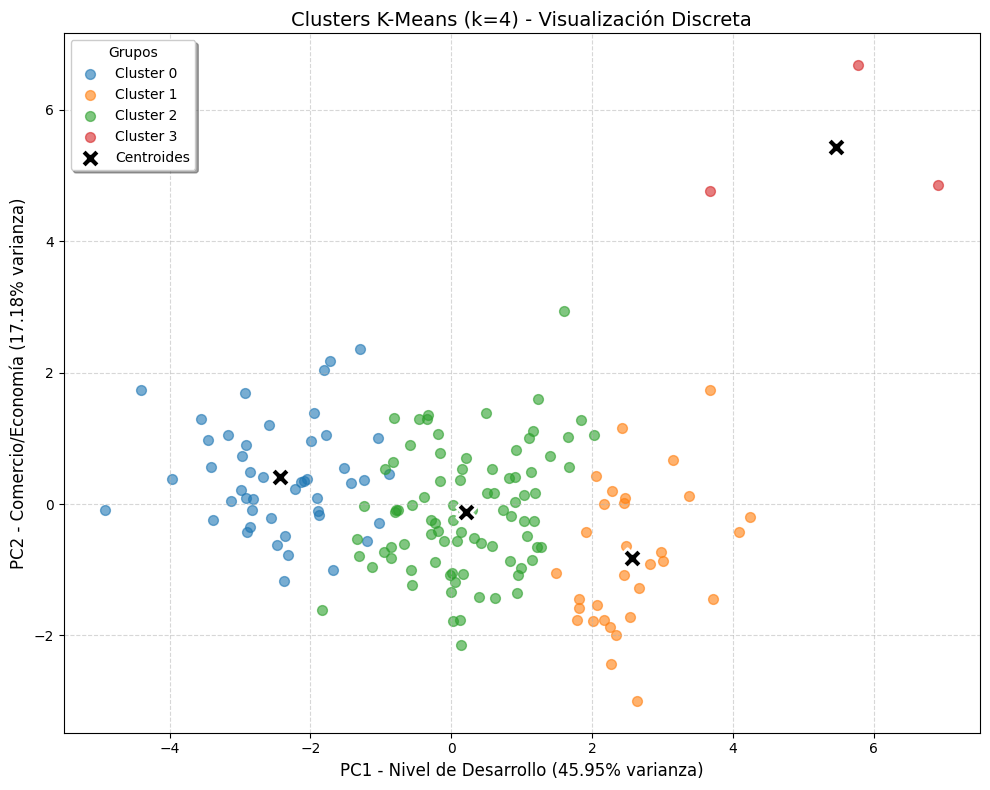

In [30]:
# GRAFICO D: Visualización en 2D (PC1 vs PC2) con Centroides

plt.figure(figsize=(10, 8))

# Definimos una paleta de colores
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Azul, Naranja, Verde, Rojo

# Bucle para dibujar cada cluster por separado y asignarle su etiqueta en la leyenda
for i in range(4):
    # Filtramos los puntos que pertenecen al cluster 'i'
    points = X_pca_4[labels == i]
    
    plt.scatter(points[:, 0], points[:, 1], 
                s=50,                  # Tamaño del punto
                c=colors[i],           # Color fijo para este cluster
                alpha=0.6,             # Transparencia
                label=f'Cluster {i}')  # Etiqueta para la leyenda

# Dibujar los centroides
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], 
            c='black', s=200, marker='X', 
            label='Centroides', edgecolors='white', linewidth=2)

# Títulos y Ejes
plt.title('Clusters K-Means (k=4) - Visualización Discreta', fontsize=14)
plt.xlabel(f'PC1 - Nivel de Desarrollo ({pca_full.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
plt.ylabel(f'PC2 - Comercio/Economía ({pca_full.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)

# Añadir la leyenda en una posición óptima
plt.legend(title="Grupos", loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
# Creamos un DataFrame que contiene las coordenadas del gráfico y el cluster asignado
df_grafico = pd.DataFrame({
    'Country': data['country'],        # Nombre del país
    'PC1': X_pca_4[:, 0],        # Coordenada X del gráfico
    'PC2': X_pca_4[:, 1],        # Coordenada Y del gráfico
    'Cluster': labels                  # Color (grupo)
})


df_grafico.sample(20)

,Country,PC1,PC2,Cluster
70,Indonesia,-0.95,-0.73,2
42,Cyprus,2.17,-0.00,1
118,Paraguay,0.12,0.36,2
133,Singapore,5.78,6.68,3
103,Mongolia,-0.94,0.53,2
165,Yemen,-1.89,-0.11,0
149,Timor-Leste,-2.37,-1.18,0
120,Philippines,-0.78,-0.10,2
81,Kiribati,-1.24,0.37,0
162,Vanuatu,-0.82,0.64,2


In [32]:
# Pesos (Loadings) de las variables originales

components_matrix = pca_4.components_
feature_names = X_raw.columns

# Crear el DataFrame con los pesos
df_loadings = pd.DataFrame(
    components_matrix,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(components_matrix))]
)

df_loadings

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
PC1,-0.42,0.28,0.15,0.16,0.40,-0.19,0.43,-0.40,0.39
PC2,0.19,0.61,-0.24,0.67,0.02,-0.01,-0.22,0.16,-0.05
PC3,-0.03,0.14,-0.60,-0.30,0.30,0.64,0.11,0.02,0.12
PC4,0.37,0.00,0.46,-0.07,0.39,0.15,-0.20,0.38,0.53


#### **PC1 (El Eje X - Nivel de Desarrollo):**

- Tiene pesos positivos fuertes en: life_expec (0.43), income (0.40), gdpp (0.39).

- Tiene pesos negativos fuertes en: child_mort (-0.42), total_fer (-0.40).

- **Conclusión:** Cuanto más a la derecha (mayor valor positivo) esté un punto, más rico, más longevo y con menos natalidad es el país. Cuanto más a la izquierda (valor negativo), más pobre, con mayor mortalidad infantil y mayor fertilidad.

#### **PC2 (El Eje Y - Comercio/Economía abierta):**

- Tiene pesos positivos muy fuertes en: imports (0.67) y exports (0.61).

- **Conclusión:** Cuanto más arriba, más depende el país del comercio internacional (importa/exporta mucho). Cuanto más abajo, economía más cerrada o doméstica.

    - **Estados Unidos (PC2 = -3.00):** Aunque EE.UU. exporta miles de millones, su economía interna es tan gigantesca que las exportaciones representan un porcentaje "bajo" de su PIB total (aprox 10-15%). Por eso aparece en la parte negativa (bajo % de dependencia comercial).

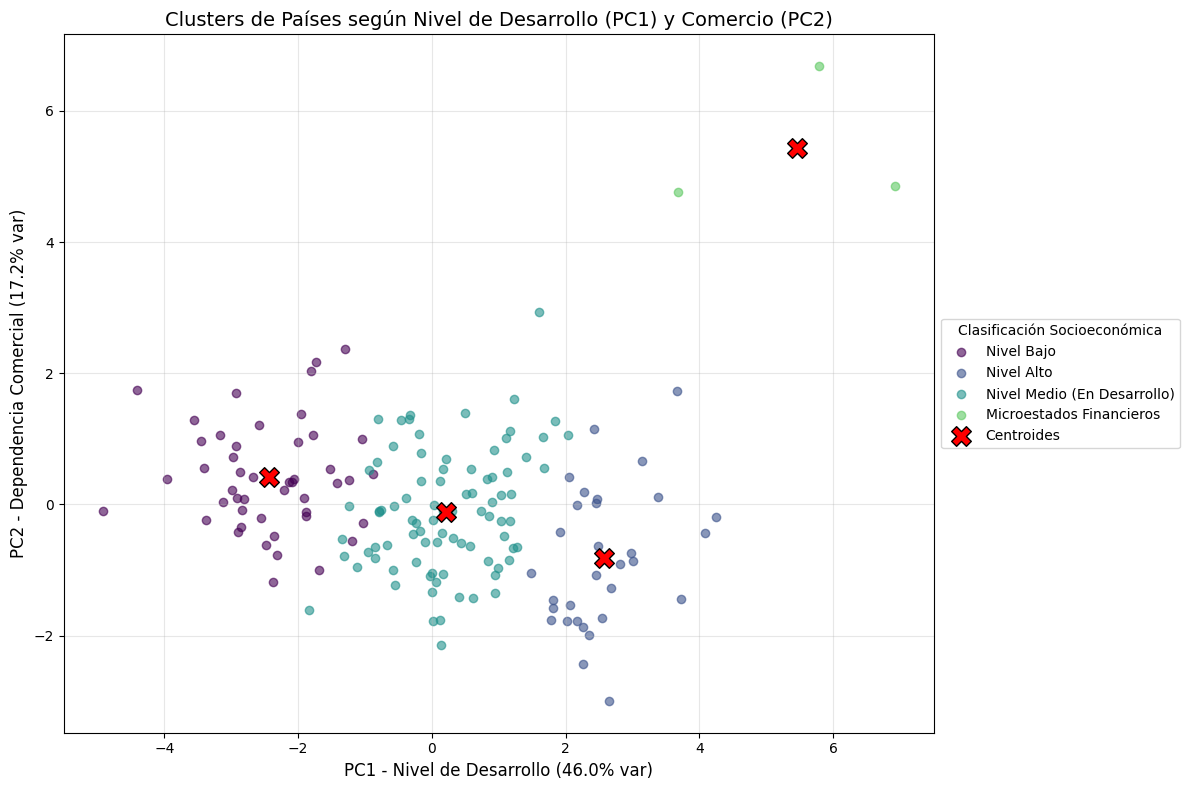


>>> Asignación automática de etiquetas basada en PC1:
  Cluster 0 -> Nivel Bajo (PC1 promedio: -2.43)
  Cluster 2 -> Nivel Medio (En Desarrollo) (PC1 promedio: 0.21)
  Cluster 1 -> Nivel Alto (PC1 promedio: 2.57)
  Cluster 3 -> Microestados Financieros (PC1 promedio: 5.46)


In [33]:
# GRAFICO D MEJORADO: Leyenda Semántica
# -----------------------------------------------------------
plt.figure(figsize=(12, 8))

# 1. Definir etiquetas basadas en la posición en PC1 (Nivel de Desarrollo)
# Obtenemos el centroide en X (PC1) para cada cluster
centroids_x = kmeans_final.cluster_centers_[:, 0]

# Creamos una lista de tuplas (cluster_id, valor_pc1) y la ordenamos
sorted_clusters = sorted(enumerate(centroids_x), key=lambda x: x[1])

# Nombres que queremos asignar (del más bajo al más alto PC1)
# Como k=4, definimos 4 niveles
nombres_niveles = [
    "Nivel Bajo",
    "Nivel Medio (En Desarrollo)",
    "Nivel Alto",
    "Microestados Financieros"
]

# Crear un diccionario de mapeo: {cluster_id: "Nombre Etiqueta"}
mapa_etiquetas = {}
for i, (cluster_id, val_x) in enumerate(sorted_clusters):
    if i < len(nombres_niveles):
        mapa_etiquetas[cluster_id] = nombres_niveles[i]
    else:
        mapa_etiquetas[cluster_id] = f"Cluster {cluster_id}"

# 2. Dibujar cada cluster por separado para asignar su etiqueta en la leyenda
colors = plt.cm.viridis(np.linspace(0, 1, 5)) # Generar 5 colores del mapa viridis

for cluster_id in range(4):
    # Seleccionar puntos de este cluster
    mask = (labels == cluster_id)
    pts = X_pca_4[mask]
    
    # Dibujar puntos
    plt.scatter(pts[:, 0], pts[:, 1], 
                color=colors[cluster_id], 
                alpha=0.6, 
                label=mapa_etiquetas[cluster_id]) # Usamos el nombre mapeado

# 3. Dibujar los centroides
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolors='black', label='Centroides', zorder=10)

plt.title('Clusters de Países según Nivel de Desarrollo (PC1) y Comercio (PC2)', fontsize=14)
plt.xlabel(f'PC1 - Nivel de Desarrollo ({pca_full.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
plt.ylabel(f'PC2 - Dependencia Comercial ({pca_full.explained_variance_ratio_[1]:.1%} var)', fontsize=12)

# Colocar la leyenda fuera o en una esquina óptima
plt.legend(title="Clasificación Socioeconómica", loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir la asignación para que la verifiques
print("\n>>> Asignación automática de etiquetas basada en PC1:")
for cluster_id, etiqueta in mapa_etiquetas.items():
    print(f"  Cluster {cluster_id} -> {etiqueta} (PC1 promedio: {centroids_x[cluster_id]:.2f})")

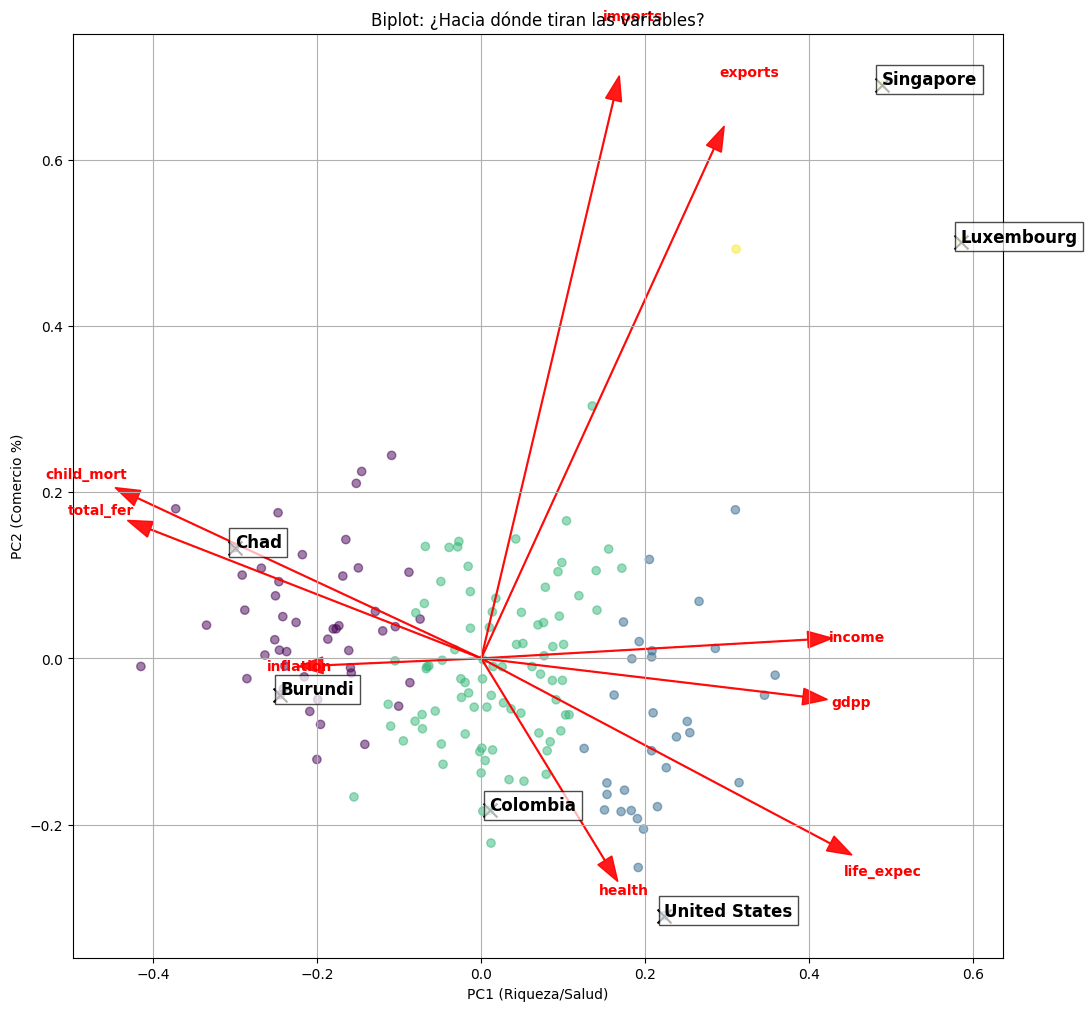

In [34]:
def my_biplot(score, coeff, labels=None, specific_countries=None, country_names=None):
    plt.figure(figsize=(12, 12))
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    
    # Escalar los vectores para que se vean bien con los puntos
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    
    # Dibujar puntos
    scatter = plt.scatter(xs * scalex, ys * scaley, c=labels, cmap='viridis', alpha=0.5)
    
    # Dibujar flechas de las variables
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='r', alpha=0.9, head_width=0.02) 
        plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, list(X_raw.columns)[i], color='r', ha='center', va='center', weight='bold')

    # Etiquetar países específicos para ver dónde caen
    if specific_countries is not None and country_names is not None:
        for country in specific_countries:
            try:
                idx = country_names[country_names == country].index[0]
                plt.text(xs[idx] * scalex, ys[idx] * scaley, country, color='black', weight='bold', fontsize=12, 
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))
                # Marcar el punto específico
                plt.scatter(xs[idx] * scalex, ys[idx] * scaley, color='black', marker='x', s=100)
            except IndexError:
                pass

    plt.xlabel("PC1 (Riqueza/Salud)")
    plt.ylabel("PC2 (Comercio %)")
    plt.title("Biplot: ¿Hacia dónde tiran las variables?")
    plt.grid()
    plt.show()


paises_a_destacar = ['United States', 'Chad', 'Luxembourg', 'Burundi', 'Singapore', 'Colombia']
my_biplot(X_pca_4, np.transpose(pca_4.components_[0:2, :]), labels=labels, 
          specific_countries=paises_a_destacar, country_names=data['country'])

In [35]:
df_loadings

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
PC1,-0.42,0.28,0.15,0.16,0.40,-0.19,0.43,-0.40,0.39
PC2,0.19,0.61,-0.24,0.67,0.02,-0.01,-0.22,0.16,-0.05
PC3,-0.03,0.14,-0.60,-0.30,0.30,0.64,0.11,0.02,0.12
PC4,0.37,0.00,0.46,-0.07,0.39,0.15,-0.20,0.38,0.53


#### 1. La Longitud: Importancia y Representatividad
La longitud de la flecha te indica qué tan bien representada está esa variable en las dos dimensiones que estás viendo (PC1 y PC2).

Flecha Larga: Significa que la variable tiene una fuerte influencia en la definición de estas dos componentes principales. La mayor parte de la información (varianza) de esa variable está contenida en este plano 2D.

Ejemplo: En tus datos, income y child_mort seguramente tendrán flechas largas porque son determinantes para distinguir países ricos de pobres (PC1).

Flecha Corta: Significa que la variable no está bien representada en este plano 2D. Su información se ha "perdido" en la proyección porque esa variable probablemente sea importante en la PC3 o PC4, pero no en la 1 y 2.

Interpretación: Si ves una flecha muy corta, no confíes mucho en su posición en este gráfico, porque estamos viendo solo su "sombra".

#### 2. El Ángulo entre flechas: Correlación
Además de la longitud, el ángulo entre dos flechas te dice cómo se relacionan las variables entre sí:

Flechas juntas (ángulo < 90°): Correlación Positiva. Si una sube, la otra sube.

Ejemplo: income y gdpp deberían apuntar casi a la misma dirección (muy pegadas).

Flechas opuestas (ángulo ~ 180°): Correlación Negativa. Si una sube, la otra baja.

Ejemplo: child_mort y life_expec deberían apuntar en direcciones totalmente opuestas.

Flechas en ángulo recto (90°): Sin Correlación. Son variables independientes entre sí en este plano.

#### 3. La Dirección (Hacia dónde apunta)
Te indica a qué Componente Principal contribuye más:

Si la flecha es muy horizontal: La variable influye casi totalmente en el PC1 (Riqueza/Salud).

Si la flecha es muy vertical: La variable influye casi totalmente en el PC2 (Comercio/Economía).

## INTERPRETACIÓN GRÁFICA

In [36]:
df_mapa = data.copy()
df_mapa['Cluster_ID'] = labels  # Asignamos los clusters numéricos (0, 1, 2, 3)

# 2. Aplicar tu leyenda exacta (mapa_etiquetas)
# Esto traduce "0" -> "Nivel Bajo", "1" -> "Nivel Alto", etc.
df_mapa['Categoria'] = df_mapa['Cluster_ID'].map(mapa_etiquetas)

# 3. Definir colores específicos para tu leyenda
# Aseguramos que el color coincida con el significado semántico
colores_semanticos = {
    "Nivel Bajo": "red",
    "Nivel Medio (En Desarrollo)": "orange",
    "Nivel Alto": "green",
    "Microestados Financieros": "blue"
}

# 4. Generar el mapa
fig = px.choropleth(
    df_mapa,
    locationmode='country names',
    locations='country',          # Columna con nombres de países
    color='Categoria',            # Columna con tus etiquetas en texto
    title='Clasificación Socioeconómica Mundial (K-Means Clustering)',
    color_discrete_map=colores_semanticos, # Aplicar nuestros colores fijos
    hover_name='country',
    projection='natural earth',   # Proyección esférica
    category_orders={"Categoria": [ # Ordenar la leyenda lógicamente
        "Nivel Bajo", 
        "Nivel Medio (En Desarrollo)", 
        "Nivel Alto", 
        "Microestados Financieros"
    ]}
)

# 5. Ajustes finales de diseño
fig.update_geos(
    visible=True,
    showcountries=True, countrycolor="Black",
    showcoastlines=True,
    showocean=True, oceancolor="#f0f9ff",
    fitbounds="locations"
)

fig.update_layout(
    legend_title_text='Nivel de Desarrollo',
    title_x=0.5,
    margin={"r":0,"t":50,"l":0,"b":0},
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

# ANÁLISIS DE LOS PAÍSES POBRES

In [37]:
# 1. Cargar los datos
data = pd.read_csv('data/Country-data.csv')
data.head()
X = data.drop('country', axis=1)

In [38]:
# 2. Escalar Globalmente
scaler_global = StandardScaler()
X_global_scaled = scaler_global.fit_transform(X)

# 3. PCA Global (4 componentes)
pca_global = PCA(n_components=4)
X_global_pca = pca_global.fit_transform(X_global_scaled)

# 4. K-Means Global (k=4)
kmeans_global = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_global = kmeans_global.fit_predict(X_global_pca)

In [39]:
# 5. Identificar el cluster más pobre (Menor PC1 promedio)
# PC1 suele ser "Riqueza/Desarrollo". Buscamos el valor más bajo.
cluster_metrics = pd.DataFrame({'Cluster': labels_global, 'PC1': X_global_pca[:, 0]})
id_cluster_pobre = cluster_metrics.groupby('Cluster')['PC1'].mean().idxmin()

print(f">>> FASE 1 COMPLETADA. El Cluster más pobre es el nº {id_cluster_pobre}")




>>> FASE 1 COMPLETADA. El Cluster más pobre es el nº 0


In [40]:
# 6. Generar dataframe con el cluster de los países más pobres
data['Global_Cluster'] = labels_global
df_pobres = data[data['Global_Cluster'] == id_cluster_pobre].copy()

# Guardamos los nombres para referencia final
paises_pobres_nombres = df_pobres['country'].values

# Nos quedamos solo con las columnas numéricas originales
X_pobres_raw = df_pobres.drop(['country', 'Global_Cluster'], axis=1)

print(f">>> FASE 2 INICIADA. Analizando subgrupo de {len(X_pobres_raw)} países.")
X_pobres_raw.shape

>>> FASE 2 INICIADA. Analizando subgrupo de 47 países.


(47, 9)

In [41]:
X_pobres_raw.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
3,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
17,111.00,23.80,4.10,37.20,1820,0.89,61.80,5.36,758
21,52.50,43.60,8.30,51.30,13300,8.92,57.10,2.88,6350
25,116.00,19.20,6.74,29.60,1430,6.81,57.90,5.87,575


In [42]:
# 7. Re-escalar (Nuevo Scaler solo para este grupo)
scaler_local = StandardScaler()
X_pobres_scaled = scaler_local.fit_transform(X_pobres_raw)

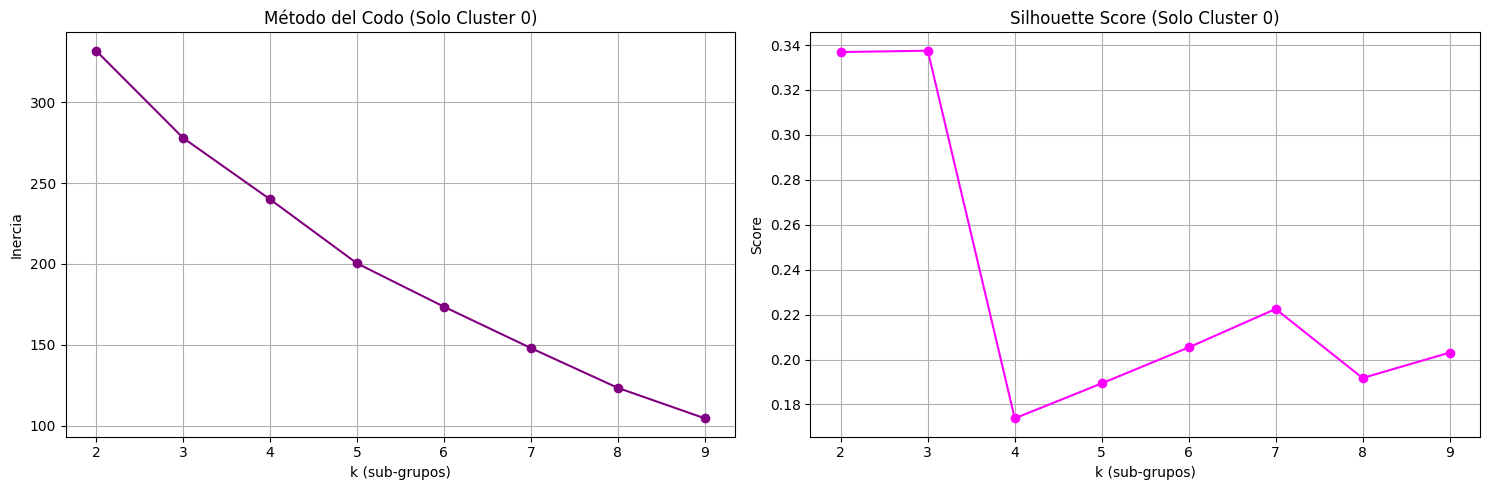

In [43]:
# 8. Gráficas de Codo y Silhouette para el SUB-GRUPO
inertia = []
silhouette_scores = []
# Probamos k de 2 a 10 (o menos si hay pocos datos)
k_range_sub = range(2, 10) 

for k in k_range_sub:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pobres_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pobres_scaled, km.labels_))

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Codo
ax[0].plot(k_range_sub, inertia, marker='o', color='purple')
ax[0].set_title(f'Método del Codo (Solo Cluster {id_cluster_pobre})')
ax[0].set_xlabel('k (sub-grupos)')
ax[0].set_ylabel('Inercia')
ax[0].grid(True)

# Silhouette
ax[1].plot(k_range_sub, silhouette_scores, marker='o', color='magenta')
ax[1].set_title(f'Silhouette Score (Solo Cluster {id_cluster_pobre})')
ax[1].set_xlabel('k (sub-grupos)')
ax[1].set_ylabel('Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [44]:
# 9. Kmeans (k =3)
k_sub = 3

kmeans_sub = KMeans(n_clusters=k_sub, random_state=42, n_init=10)
labels_sub = kmeans_sub.fit_predict(X_pobres_scaled)

df_pobres['Sub_Cluster'] = labels_sub

In [45]:
# 10. Listado de países

for i in range(k_sub):
    paises = df_pobres[df_pobres['Sub_Cluster'] == i]['country'].values
    print(f"\n--- Sub-Cluster {i} ({len(paises)} países) ---")
    print(", ".join(paises))


--- Sub-Cluster 0 (36 países) ---
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Cote d'Ivoire, Eritrea, Gambia, Ghana, Guinea, Guinea-Bissau, Kenya, Lao, Madagascar, Malawi, Mali, Mauritania, Mozambique, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

--- Sub-Cluster 1 (7 países) ---
Botswana, Congo, Rep., Equatorial Guinea, Gabon, Iraq, Namibia, South Africa

--- Sub-Cluster 2 (4 países) ---
Haiti, Kiribati, Lesotho, Liberia


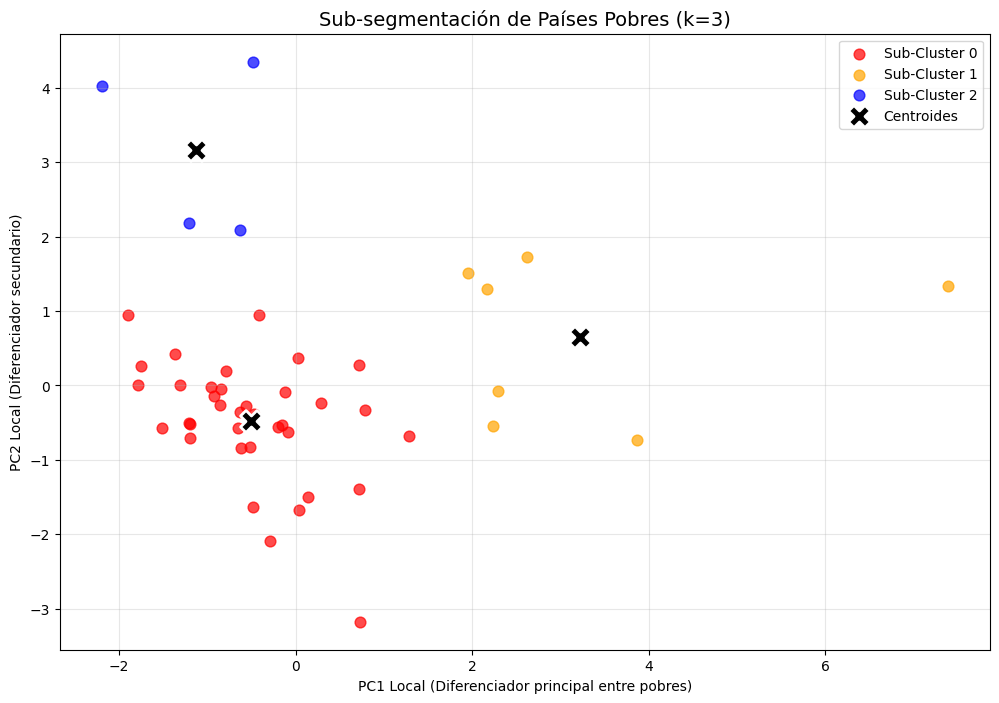

In [46]:
# 11. Visualización con PCA

pca_local = PCA(n_components=2)
X_pobres_pca = pca_local.fit_transform(X_pobres_scaled)

centroids_local_pca = pca_local.transform(kmeans_sub.cluster_centers_)

plt.figure(figsize=(12, 8))

colors = ['red', 'orange', 'blue']
for i in range(k_sub):
    subset = X_pobres_pca[labels_sub == i]
    plt.scatter(subset[:, 0], subset[:, 1], c=colors[i], label=f'Sub-Cluster {i}', s=60, alpha=0.7)

# 2. Dibujar Centroides
plt.scatter(centroids_local_pca[:, 0], centroids_local_pca[:, 1], 
            c='black', 
            s=250,          # Tamaño grande para destacar
            marker='X',     # Forma de X
            label='Centroides', 
            edgecolors='white', # Borde blanco para contraste
            linewidth=2,
            zorder=10)      # zorder alto para que se pinte encima de todo

plt.title(f'Sub-segmentación de Países Pobres (k={k_sub})', fontsize=14)
plt.xlabel('PC1 Local (Diferenciador principal entre pobres)')
plt.ylabel('PC2 Local (Diferenciador secundario)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
# 12. Interpretación de los resultados de clustering

# Calculamos la media de las variables ORIGINALES para cada sub-cluster
# Esto es vital para ponerles nombre (ej. "Alta Inflación", "Mortalidad Extrema")
perfil_pobreza = df_pobres.groupby('Sub_Cluster')[['child_mort', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']].mean()
 
print("\n>>> PERFIL DE LOS SUB-GRUPOS (Promedios Originales):")
print(perfil_pobreza)


>>> PERFIL DE LOS SUB-GRUPOS (Promedios Originales):
             child_mort   income  inflation  life_expec  total_fer    gdpp
Sub_Cluster                                                               
0                 96.44  2173.14      12.52       60.01       5.33  966.47
1                 62.53 14392.86      13.95       60.20       3.98 7415.71
2                114.92  1577.50       4.15       50.02       3.87  912.25


#### 1. Sub-Cluster 1: "La Paradoja de los Recursos" (Ricos pero con mala salud)

**Países:** Botswana, Congo (Rep), Equatorial Guinea, Gabon, Iraq, Namibia, South Africa.

Este es el grupo más sorprendente:

- Income ($14,393): ¡Es 7 veces más alto que los otros dos grupos!

- GDPP ($7,415): Muy superior.

- Life Expectancy (60.2): Es igual de baja que el Cluster 0.

- Child Mortality (62.5): Sigue siendo alta para ese nivel de ingresos.

**Diagnóstico:** Son países con economías extractivas (petróleo, diamantes, minerales) o desigualdades extremas. Tienen dinero a nivel macroeconómico (PIB alto), pero ese dinero no se traduce en bienestar social ni salud para la población general.

**Ejemplo:** Guinea Ecuatorial y Gabón tienen mucho petróleo (PIB alto), pero sus sistemas de salud son precarios. Sudáfrica tiene una gran economía, pero una desigualdad y problemas de salud pública masivos.


#### 2. Sub-Cluster 2: "Crisis Humanitaria Aguda / Estado Crítico"

**Países:** Haiti, Kiribati, Lesotho, Liberia.

Este es el grupo más vulnerable y trágico de todos.

- Child Mortality (114.92): La más alta de todas. Más de 1 de cada 10 niños muere.

- Life Expectancy (50.02): Dato Alarmante. La esperanza de vida es 10 años menor que en los otros grupos pobres. La gente muere a los 50 años en promedio.

- Income ($1,577): Los más pobres económicamente.

**Diagnóstico:** Son "Estados Frágiles" o países que han sufrido catástrofes recientes (naturales o políticas) que han destruido su estructura vital.

**Ejemplo:** Haití (desastres naturales y crisis política), Liberia (secuelas de guerra civil/ébola), Lesotho (crisis de VIH que reduce drásticamente la esperanza de vida).


#### 3. Sub-Cluster 0: "Pobreza Estructural y Agraria" (El grueso del tercer mundo)

**Países:** Afganistán, Angola, Camerún, Kenia, Nigeria, Pakistán, etc. (36 países)

Es el grupo más numeroso y representa el perfil "clásico" de país en vías de desarrollo estancado.

- Total Fertility (5.33): El dato clave. Es la tasa de natalidad más alta. Son poblaciones muy jóvenes creciendo muy rápido.

- Income (~$2,173) y GDPP (~$966): Economía de subsistencia, muy baja.

- Child Mortality (96.44): Muy alta.

**Diagnóstico:** Países atrapados en la trampa malthusiana. La economía crece poco y la población crece mucho. Tienen alta mortalidad, pero también altísima natalidad- 